In [2]:
import glob 
import numpy as np 
import pandas as pd 

from __future__ import absolute_import

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import xarray as xr 
import concurrent.futures
import tqdm 
from tqdm.contrib.concurrent import process_map
import os
from dask.distributed import Client
from dask_jobqueue import SLURMCluster

import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import copy

import pandas as pd 
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import copy

import matplotlib

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
import copy

import matplotlib.ticker as mticker



/home/rauth/miniforge3/envs/research/lib/python3.12/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


In [3]:
def percentile(n):
    def percentile_(x):
        return np.nanpercentile(x, n)
    percentile_.__name__ = 'percentile_%s' % n
    return percentile_

#determine unconditional mean, sum R in each bin. But then devide by master counts
def boxbin(x,y,xedge,yedge,c=None,figsize=(5,5),cmap='viridis',mincnt=10,vmin=0,vmax=2500,edgecolor=None,powernorm=False,
           ax=None,normed=False,method='mean',quantile=None,alpha=1.0,cbar=True,unconditional=False,master_count=np.array([]),shrink=1):
    
    """ This function will grid data for you and provide the counts if no variable c is given, or the median if 
    a variable c is given. In the future I will add functionallity to do the median, and possibly quantiles. 
    
    x: 1-D array 
    y: 1-D array 
    xedge: 1-D array for xbins 
    yedge: 1-D array for ybins
    
    c: 1-D array, same len as x and y 
    
    returns
    
    axis handle 
    cbar handle 
    C matrix (counts or median values in bin)
    
    """
    
    midpoints = np.empty(xedge.shape[0]-1)
    for i in np.arange(1,xedge.shape[0]):
        midpoints[i-1] = xedge[i-1] + (np.abs(xedge[i] - xedge[i-1]))/2.
    
    #note on digitize. bin 0 is outside to the left of the bins, bin -1 is outside to the right
    ind1 = np.digitize(x,bins = xedge) #inds of x in each bin
    ind2 = np.digitize(y,bins = yedge) #inds of y in each bin
    
    
    #drop points outside range 
    outsideleft = np.where(ind1 != 0)
    ind1 = ind1[outsideleft]
    ind2 = ind2[outsideleft]
    if c is None:
        pass
    else:
        c = c[outsideleft]
        
    outsideright = np.where(ind1 != len(xedge))
    ind1 = ind1[outsideright]
    ind2 = ind2[outsideright]
    if c is None:
        pass
    else:
        c = c[outsideright]
        
    outsideleft = np.where(ind2 != 0)
    ind1 = ind1[outsideleft]
    ind2 = ind2[outsideleft]
    if c is None:
        pass
    else:
        c = c[outsideleft]
    outsideright = np.where(ind2 != len(yedge))
    ind1 = ind1[outsideright]
    ind2 = ind2[outsideright]
    if c is None:
        pass
    else:
        c = c[outsideright]
    

    if c is None:
        c = np.zeros(len(ind1))
        df = pd.DataFrame({'x':ind1-1,'y':ind2-1,'c':c})
        df2 = df.groupby(["x","y"]).count()
        df = df2.where(df2.values >= mincnt).dropna()
        C = np.ones([xedge.shape[0]-1,yedge.shape[0]-1])*-9999
        for i,ii in enumerate(df.index.values):
            C[ii[0],ii[1]] = df.c.values[i]
        C = np.ma.masked_where(C == -9999,C)
        
        if normed:
            n_samples = np.ma.sum(C)
            C = C/n_samples
            C = C*100
            print('n_samples= {}'.format(n_samples))
        
        if ax is None:
            fig, ax = plt.subplots(nrows =1, ncols = 1, subplot_kw = {'projection':ccrs.PlateCarree()})
            #ax = plt.gca() 

            ax.add_feature(cfeature.LAND,facecolor=[0.9,0.9,0.9])
            ax.add_feature(cfeature.OCEAN)
            ax.add_feature(cfeature.COASTLINE)
            ax.add_feature(cfeature.STATES, linewidth=0.5, edgecolor='black')
            ax.add_feature(cfeature.BORDERS, linestyle=':')
            ax.add_feature(cfeature.LAKES, alpha=0.5)

        else:
            pass
            
        if powernorm:
            pm = ax.pcolormesh(xedge,yedge,C.transpose(),cmap=cmap,edgecolor=edgecolor,norm=colors.PowerNorm(gamma=0.5),vmin=vmin,vmax=vmax,alpha=alpha)
            
            if cbar:
                cbar = plt.colorbar(pm,ax=ax,shrink=shrink)
            else:
                cbar = pm 
        else:
            pm = ax.pcolormesh(xedge,yedge,C.transpose(),cmap=cmap,vmin=vmin,vmax=vmax,edgecolor=edgecolor,alpha=alpha)
            if cbar:
                cbar = plt.colorbar(pm,ax=ax,shrink=shrink)
            else:
                cbar = pm 
            
        return ax,cbar,C,df
    
    elif unconditional:
    
        df = pd.DataFrame({'x':ind1-1,'y':ind2-1,'c':c})
        if method=='mean':
            df2 = df.groupby(["x","y"])['c'].sum()
            
        df3 = df.groupby(["x","y"]).count()
        df2 = df2.to_frame()
        df2.insert(1,'Count',df3.values)
        df = df2.where(df2.Count >= mincnt).dropna()
        C = np.ones([xedge.shape[0]-1,yedge.shape[0]-1])
        for i,ii in enumerate(df.index.values):
            C[ii[0],ii[1]] = df.c.values[i]
                
        C = C/master_count.values

        if ax is None:
            fig = plt.figure(figsize=(5,5))
            ax = plt.gca()

        else:
            pass
        
        if powernorm:
            pm = ax.pcolor(xedge,yedge,C.transpose(),cmap=cmap,vmin=vmin,vmax=vmax,norm=colors.PowerNorm(gamma=0.5),alpha=alpha)
            if cbar:
                cbar = plt.colorbar(pm,ax=ax,shrink=shrink)
        else:
            
            pm = ax.pcolor(xedge,yedge,C.transpose(),cmap=cmap,vmin=vmin,vmax=vmax,alpha=alpha)
            if cbar: 
                cbar = plt.colorbar(pm,ax=ax,shrink=shrink)
        
        
    else:
        df = pd.DataFrame({'x':ind1-1,'y':ind2-1,'c':c})
        if method=='mean':
            df2 = df.groupby(["x","y"])['c'].mean()
        elif method=='std':
            df2 = df.groupby(["x","y"])['c'].std()
        elif method=='median':
            df2 = df.groupby(["x","y"])['c'].median()
        elif method=='quantile':
            if quantile is None:
                print('No quantile given, defaulting to median')
                quantile = 0.5
            else:
                pass
            df2 = df.groupby(["x","y"])['c'].apply(percentile(quantile*100))
            
            
        df3 = df.groupby(["x","y"]).count()
        df2 = df2.to_frame()
        df2.insert(1,'Count',df3.values)
        df = df2.where(df2.Count >= mincnt).dropna()
        C = np.ones([xedge.shape[0]-1,yedge.shape[0]-1])*-9999
        for i,ii in enumerate(df.index.values):
            C[ii[0],ii[1]] = df.c.values[i]

        C = np.ma.masked_where(C == -9999,C)

        if ax is None:
            fig = plt.figure(figsize=(5,5))
            ax = plt.gca()

        else:
            pass
        
        if powernorm:
            pm = ax.pcolor(xedge,yedge,C.transpose(),cmap=cmap,vmin=vmin,vmax=vmax,norm=colors.PowerNorm(gamma=0.5),alpha=alpha)
            if cbar:
                cbar = plt.colorbar(pm,ax=ax,shrink=shrink)
            else:
                cbar = pm
        else:
            
            pm = ax.pcolor(xedge,yedge,C.transpose(),cmap=cmap,vmin=vmin,vmax=vmax,alpha=alpha)
            if cbar: 
                cbar = plt.colorbar(pm,ax=ax,shrink=shrink)
            else:
                cbar = pm 
            
    return ax,cbar,C

In [3]:
files = (
    glob.glob('/tempest/rauth/goes-data/combined_nc_dir/2022*/*') +
    glob.glob('/tempest/rauth/goes-data/combined_nc_dir/2023*/*') +
    glob.glob('/tempest/rauth/goes-data/combined_nc_dir/2024*/*') +
    glob.glob('/tempest/rauth/goes-data/combined_nc_dir/2025*/*')
)
files.sort()
df = pd.DataFrame({'filepaths':np.asarray(files)})
df_split = df.filepaths.str.split('/',expand=True)
df['len_of_date'] = df_split[5].str.len()

df = df[df.len_of_date == 8]
df['date'] = pd.to_datetime(df.filepaths.str.split('/',expand=True)[5])
df = df[(df.date != np.datetime64('2024-10-28')) & 
    (df.date != np.datetime64('2025-02-20')) & 
        (df.date != np.datetime64('2025-11-06'))]

In [4]:
all_dates = np.unique(df.date.dt.strftime('%Y%m%d').values)
for date in tqdm.tqdm(all_dates): 
    save_path = '/tempest/rauth/meso_grids/' + date + '/'
    os.makedirs(save_path)
    

100%|██████████| 736/736 [00:00<00:00, 1445.30it/s]


In [10]:
def get_meso_loc_para(filepath):
    ds = xr.open_dataset(filepath)
    fig,dummy_ax = plt.subplots(1,1)
    yedge = np.linspace(20, 55, 35*2)  
    xedge = np.linspace(-115, -65, 50*2)  
    midpoints_y = (yedge[:-1] + yedge[1:]) / 2
    midpoints_x = (xedge[:-1] + xedge[1:]) / 2

    ax,cbar,C,_ = boxbin(ds.longitude.values.ravel(),ds.latitude.values.ravel(),xedge,yedge,ax=dummy_ax,mincnt=0)
    plt.close(fig)
    ds_out = xr.Dataset({'count':(('xedge','yedge'),C.T),'xedges':midpoints_x,'yedges':midpoints_y})
    save_path = '/tempest/rauth/meso_grids/' + filepath.split('/')[5] + '/'
    save_name = save_path + filepath.split('/')[-1].split('.')[0] + '_gridcount.nc'
    ds_out.to_netcdf(save_name)
    ds_out.close()
    ds.close()
    return 
 

In [15]:
filepaths = df.filepaths.values
batch_size = 20000

for i in range(20000, len(filepaths), batch_size):
    start = i
    end = min(i + batch_size, len(filepaths))
    print(f"Processing files {start} to {end - 1}")

    with concurrent.futures.ProcessPoolExecutor(max_workers=18) as executor:
        futures = {
            executor.submit(get_meso_loc_para, file): file 
            for file in filepaths[start:end]
        }

        with tqdm.tqdm(total=len(futures)) as pbar:
            for future in concurrent.futures.as_completed(futures):
                try:
                    file = futures[future]
                    result = future.result(timeout=30)
                    # Handle result if needed
                except Exception as e:
                    print(f"Error processing {file}: {e}")
                pbar.update(1)


Processing files 20000 to 39999


100%|██████████| 20000/20000 [12:00<00:00, 27.77it/s]


Processing files 40000 to 59999


100%|██████████| 20000/20000 [12:15<00:00, 27.18it/s]


Processing files 60000 to 79999


...

100%|██████████| 20000/20000 [17:00<00:00, 19.60it/s]


Processing files 620000 to 639999


100%|██████████| 20000/20000 [19:53<00:00, 16.75it/s]


Processing files 640000 to 659999


 80%|███████▉  | 15936/20000 [13:53<03:46, 17.97it/s] IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



In [16]:
def load_n_sum_para(filepath):
    ds_counts = xr.open_dataset(filepath)
    C_tot = ds_counts['count'].values
    ds_counts.close()
    return C_tot

In [17]:
all_files = glob.glob('/tempest/rauth/meso_grids/20*/*.nc')
all_files.sort()
place_holder = process_map(load_n_sum_para, all_files,max_workers=18)
C_tot = np.stack(place_holder,axis=0)

/tmp/ipykernel_3886044/1929787553.py:3: TqdmWarning: Iterable length 1061575 > 1000 but `chunksize` is not set. This may seriously degrade multiprocess performance. Set `chunksize=1` or more.
  place_holder = process_map(load_n_sum_para, all_files,max_workers=18)


  0%|          | 0/1061575 [00:00<?, ?it/s]

In [18]:
C_tot_sum = np.nansum(C_tot,axis=0)

In [19]:
yedge = np.linspace(20, 55, 35*2)  
xedge = np.linspace(-115, -65, 50*2)  
midpoints_y = (yedge[:-1] + yedge[1:]) / 2
midpoints_x = (xedge[:-1] + xedge[1:]) / 2

ds_out = xr.Dataset({'total_count':(('xedge','yedge'),C_tot_sum),'xedges':midpoints_x,'yedges':midpoints_y})
ds_out.to_netcdf('/tempest/rauth/meso_grids/total_mesosector_counts.nc')

In [4]:
ds = xr.open_dataset('/tempest/rauth/meso_grids/total_mesosector_counts.nc')
ds

/home/rauth/miniforge3/envs/research/lib/python3.12/site-packages/gribapi/__init__.py:23: UserWarning: ecCodes 2.42.0 or higher is recommended. You are running version 2.41.0
  warnings.warn(


<xarray.Dataset> Size: 56kB
Dimensions:      (xedge: 69, yedge: 99, xedges: 99, yedges: 69)
Coordinates:
  * xedges       (xedges) float64 792B -114.7 -114.2 -113.7 ... -65.76 -65.25
  * yedges       (yedges) float64 552B 20.25 20.76 21.27 ... 53.73 54.24 54.75
Dimensions without coordinates: xedge, yedge
Data variables:
    total_count  (xedge, yedge) float64 55kB ...

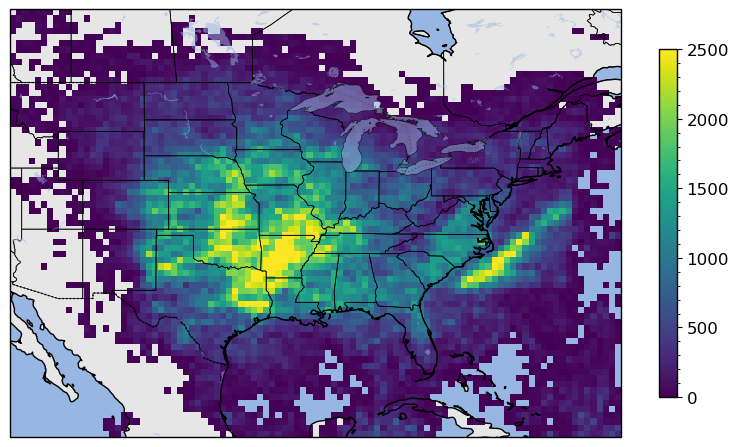

In [14]:
df=pd.read_pickle('DATA/tobac/masters_data/v9.3.7_paper/features/final_ots_matched_QC_v9.3.7_paper_M1_-20_2022_03_01_2025_08_31.p')

yedge = np.linspace(20, 55, 35*2)  
xedge = np.linspace(-115, -65, 50*2)  
midpoints_y = (yedge[:-1] + yedge[1:]) / 2
midpoints_x = (xedge[:-1] + xedge[1:]) / 2

ax,cbar,C,_ = boxbin(df.longitude.values,df.latitude.values,xedge,yedge,mincnt=1, shrink = .75)

C_tot_sum = ds.total_count
C_masked = np.where(C_tot_sum <= 1.5e8, np.nan, C_tot_sum)
normalized_OT = np.where(normalized_OT < -9000, np.nan, normalized_OT) 
normalized_OT = np.where(normalized_OT > 1e-3, np.nan, normalized_OT)
valid = np.array(normalized_OT).flatten()
valid = valid[np.isfinite(valid)]
valid = valid[valid > -9000]       # nan fill values -9999
valid = valid[valid < 1e-3]        # large blowup outliers 
C_OT_masked = np.where(C_masked > 0, C.T, np.nan)


Bad value in file 'anvil_ot.mplstyle', line 33 ("axes.prop_cycle: color cycle ['#0072B2', '#E69F00', '#009E73', '#D55E00', '#CC79A7']"): Key axes.prop_cycle: "color cycle ['" is not a valid cycler construction: unterminated string literal (detected at line 1) (<unknown>, line 1)


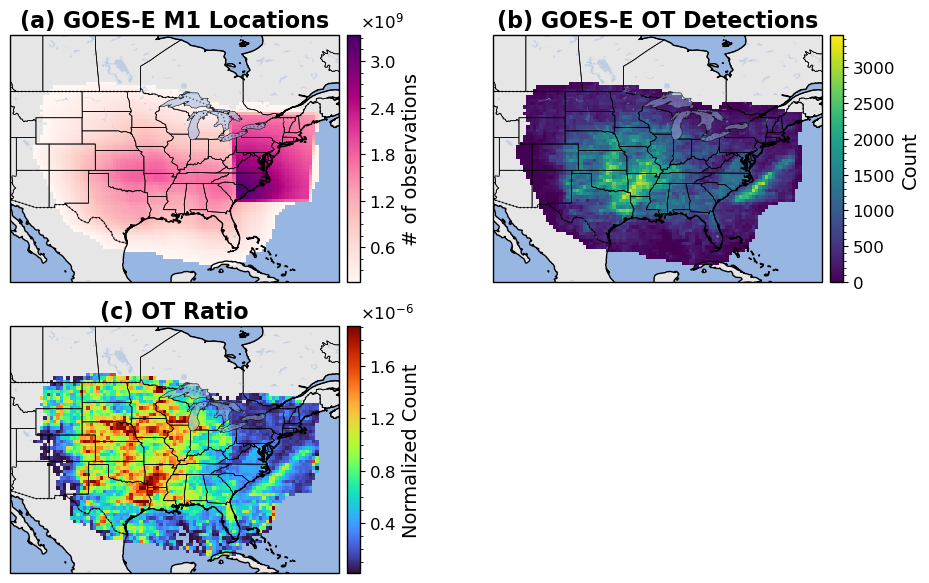

In [15]:
# plotting
SMALL_SIZE = 12      # tick labels, legend
MEDIUM_SIZE = 14     # axis labels  
LARGE_SIZE = 16      # titles

plt.style.use("anvil_ot.mplstyle") 

plt.rcParams.update({
    'font.size': SMALL_SIZE,           # default text size
    'axes.labelsize': MEDIUM_SIZE,     # x and y labels
    'axes.titlesize': LARGE_SIZE,      # subplot titles
    'xtick.labelsize': SMALL_SIZE,     # x tick labels
    'ytick.labelsize': SMALL_SIZE,     # y tick labels
    'legend.fontsize': SMALL_SIZE,     # legend
    'figure.titlesize': LARGE_SIZE,    # figure title
    'figure.dpi': 100,
    'savefig.dpi': 300,
    'font.family': 'sans-serif',
    'axes.linewidth': 1.0,
})

def add_map_features(ax):
    ax.set_extent([xedge.min(), xedge.max(), yedge.min(), yedge.max()])
    ax.add_feature(cfeature.LAND, facecolor=[0.9,0.9,0.9])
    ax.add_feature(cfeature.OCEAN)
    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.STATES, linewidth=0.5, edgecolor='black')
    ax.add_feature(cfeature.BORDERS, linestyle=':')
    ax.add_feature(cfeature.LAKES, alpha=0.5)

fig, axes = plt.subplots(2, 2, figsize=(10, 6), subplot_kw={'projection': ccrs.PlateCarree()})

axes = axes.ravel()

#Total meso1 counts
add_map_features(axes[0])
pm1 = axes[0].pcolormesh(xedge, yedge, C_masked, cmap='RdPu')
cbar1 = fig.colorbar(pm1, ax=axes[0], shrink=1, pad=0.02)
cbar1.set_label('# of observations')
axes[0].set_title('(a) GOES-E M1 Locations', fontweight='bold')

# --- Scale by 1e9 ---
scale = 1e9

def billions_formatter(x, pos):
    return f"{x/scale:.1f}"

cbar1.ax.yaxis.set_major_formatter(mticker.FuncFormatter(billions_formatter))
cbar1.ax.yaxis.set_major_locator(mticker.MaxNLocator(nbins=6))
cbar1.ax.yaxis.offsetText.set_visible(False)
cbar1.ax.text(1.05, 1.02, r'$\times 10^{9}$', transform=cbar1.ax.transAxes, ha='left', va='bottom', fontsize=SMALL_SIZE)

#Raw OT counts
add_map_features(axes[1])
pm2 = axes[1].pcolormesh(xedge, yedge, C_OT_masked, cmap='viridis', vmin=0)
cbar2 = fig.colorbar(pm2, ax=axes[1], shrink=1, pad=0.02)
cbar2.set_label('Count')
axes[1].set_title('(b) GOES-E OT Detections', fontweight='bold')

#Normalized OT (ratio OT / total)
add_map_features(axes[2])

vmin = np.percentile(valid, 1)   # 1.056e-07
vmax = np.percentile(valid, 99)  # 3.409e-06

pm3 = axes[2].pcolormesh(xedge, yedge, normalized_OT,cmap='turbo', vmin=vmin, vmax=vmax)

cbar3 = fig.colorbar(pm3, ax=axes[2], shrink=1, pad=0.02)
cbar3.set_label('Normalized Count')
axes[2].set_title('(c) OT Ratio', fontweight='bold')

# --- Scale by 1e9 ---
scale1 = 1e-6
def billions_formatter(x, pos):
    return f"{x/scale1:.1f}"

cbar3.ax.yaxis.set_major_formatter(mticker.FuncFormatter(billions_formatter))
cbar3.ax.yaxis.set_major_locator(mticker.MaxNLocator(nbins=6))
cbar3.ax.yaxis.offsetText.set_visible(False)
cbar3.ax.text(1.05, 1.02, r'$\times 10^{-6}$', transform=cbar3.ax.transAxes, ha='left', va='bottom', fontsize=SMALL_SIZE)
axes[3].axis('off')

# Layout and save
plt.tight_layout()
#plt.savefig("/tempest/rauth/meso_grids/3panel_OT_maps.png", dpi=300, bbox_inches='tight')
plt.show()